# 01 — Exploration des données (EDA)

**Projet** : FakeNews Analyzer — DevComplex  
**Version** : V1 (local PySpark)  
**Objectif** : Explorer toutes les sources ingérées, comprendre la distribution, la qualité et les patterns.

**Exécuter après** : `python 01_ingestion/downloader.py` ou `ingest_huggingface.py`

---

In [1]:
# ============================================================
# Fichier  : 01_exploration.ipynb
# Rôle     : EDA — distribution, longueurs, ratios, wordclouds
# Version  : V1 (local)
# Projet   : FakeNews Analyzer — DevComplex
# Auteur   : DevComplex
# ============================================================

import sys
import os
sys.path.insert(0, '..')  # Accès aux modules du projet

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from wordcloud import WordCloud

from spark_utils import get_spark_session, load_raw_sources, show_label_distribution

# Style matplotlib
plt.style.use('dark_background')
sns.set_palette('husl')

print('Imports OK')

Imports OK


## Section 1 — Démarrage Spark et chargement des sources

In [2]:
# Démarrer Spark (utiliser 4g si moins de 16 GB RAM disponible)
spark = get_spark_session(app_name='FakeNews-Exploration', memory='8g')

# Chemin vers les données brutes
RAW_DIR = '../09_data/raw'

# Charger toutes les sources disponibles
sources = load_raw_sources(spark, RAW_DIR)

print(f'\nSources chargées : {list(sources.keys())}')


Sources chargées : ['fake_news', 'welfake', 'fake_jobs', 'isot_fake', 'isot_true']


## Section 2 — Stats de base par source

In [3]:
# Stats de base : nb lignes, nb colonnes, schéma
for name, df in sources.items():
    print(f'\n{"="*50}')
    print(f'Source : {name}')
    print(f'  Lignes   : {df.count():,}')
    print(f'  Colonnes : {len(df.columns)}')
    print(f'  Schéma   :')
    df.printSchema()
    print(f'  Aperçu   :')
    df.show(3, truncate=80)


Source : fake_news
  Lignes   : 44,267
  Colonnes : 4
  Schéma   :
root
 |-- text: string (nullable = true)
 |-- label: string (nullable = true)
 |-- split: string (nullable = true)
 |-- source: string (nullable = true)

  Aperçu   :
+--------------------------------------------------------------------------------+-----+-----+---------+
|                                                                            text|label|split|   source|
+--------------------------------------------------------------------------------+-----+-----+---------+
|The Trump administration has been getting absolutely pummeled for its refusal...|    1|train|fake_news|
|NAIROBI (Reuters) - Kenyan police shot dead two people and wounded a third wh...|    0|train|fake_news|
|PC is killing our country. This is called fighting back While counterculture ...|    1|train|fake_news|
+--------------------------------------------------------------------------------+-----+-----+---------+
only showing top 3 rows


Sour

## Section 3 — Distribution des labels par source

In [4]:
from pyspark.sql import functions as F

# Afficher la distribution des labels pour chaque source
for name, df in sources.items():
    label_candidates = [c for c in df.columns if c.lower() in ('label', 'fraudulent', 'fake')]
    if not label_candidates:
        print(f'[{name}] Pas de colonne label détectée')
        continue
    label_col = label_candidates[0]
    print(f'\n[{name}] — colonne label : "{label_col}"')
    show_label_distribution(df, label_col)


[fake_news] — colonne label : "label"

Distribution des labels (total : 44,267)
----------------------------------------
+-----+-----+-----------+
|label|count|pourcentage|
+-----+-----+-----------+
|0    |21416|48.38      |
|1    |22851|51.62      |
+-----+-----+-----------+


[welfake] — colonne label : "label"

Distribution des labels (total : 71,351)
----------------------------------------
+-----+-----+-----------+
|label|count|pourcentage|
+-----+-----+-----------+
|0    |35027|49.09      |
|1    |36324|50.91      |
+-----+-----+-----------+


[fake_jobs] — colonne label : "fraudulent"

Distribution des labels (total : 17,880)
----------------------------------------
+----------+-----+-----------+
|fraudulent|count|pourcentage|
+----------+-----+-----------+
|0         |17014|95.16      |
|1         |866  |4.84       |
+----------+-----+-----------+


[isot_fake] — colonne label : "label"

Distribution des labels (total : 23,481)
----------------------------------------
+-----+-

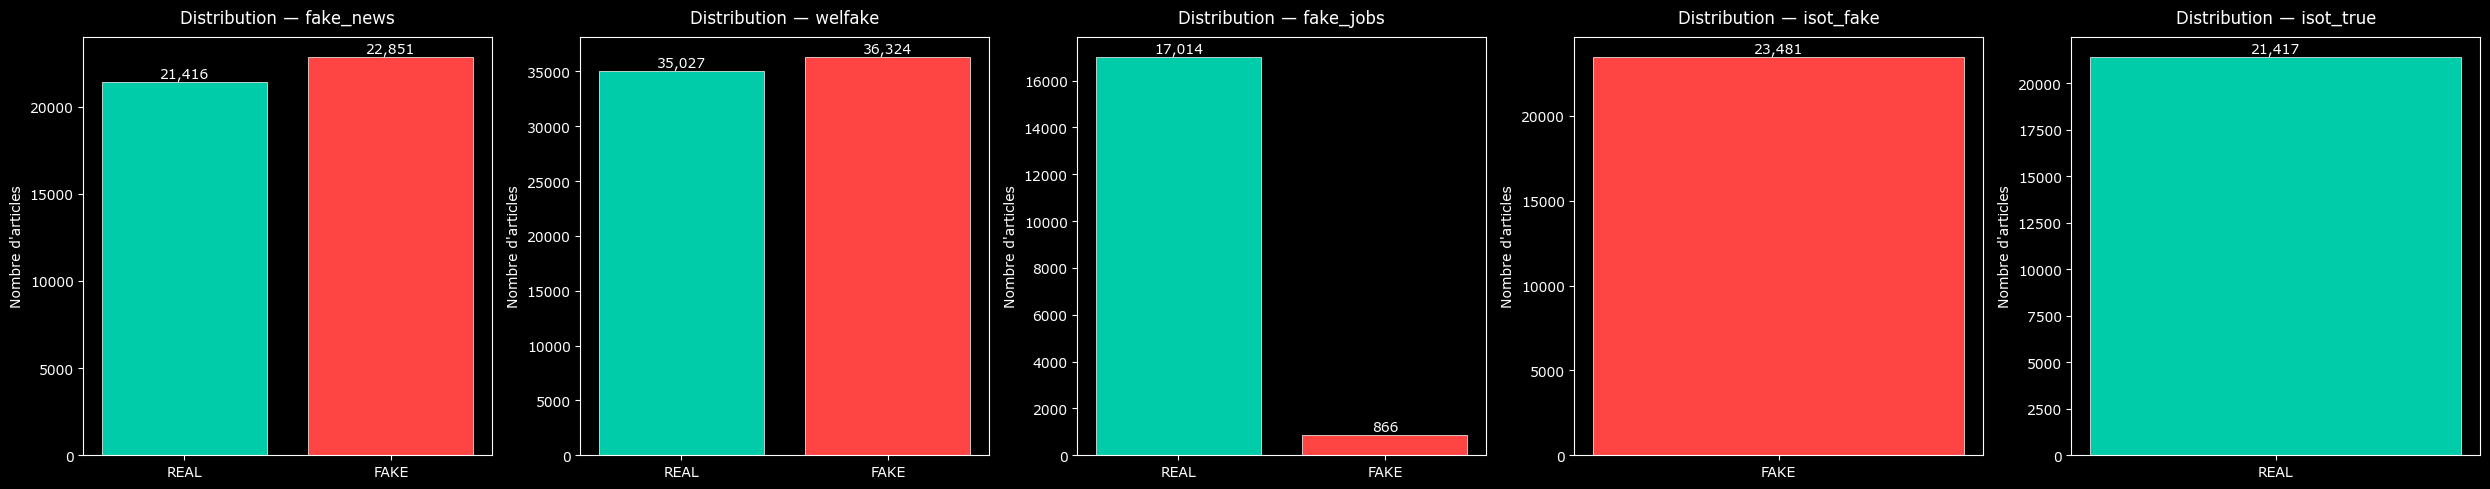

In [5]:
# Graphe matplotlib : distribution FAKE/REAL par source
fig, axes = plt.subplots(1, max(len(sources), 1), figsize=(5 * len(sources), 5))
if len(sources) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, sources.items()):
    label_candidates = [c for c in df.columns if c.lower() in ('label', 'fraudulent')]
    if not label_candidates:
        continue
    label_col = label_candidates[0]
    
    counts = df.groupBy(label_col).count().toPandas()
    counts['label_name'] = counts[label_col].apply(lambda x: 'FAKE' if str(x) in ('1', 'FAKE', 'fake') else 'REAL')
    colors = ['#ff4444' if l == 'FAKE' else '#00ccaa' for l in counts['label_name']]
    
    ax.bar(counts['label_name'], counts['count'], color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribution — {name}', fontsize=12, pad=10)
    ax.set_ylabel("Nombre d'articles")
    for bar, count in zip(ax.patches, counts['count']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
os.makedirs('../09_data/reports', exist_ok=True)
plt.savefig('../09_data/reports/01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Distribution des longueurs de texte

In [6]:
# Calculer les longueurs pour chaque source
for name, df in sources.items():
    text_candidates = [c for c in df.columns if c.lower() in ('text', 'statement', 'tweet', 'content')]
    if not text_candidates:
        continue
    text_col = text_candidates[0]
    
    df_len = df.withColumn('text_len', F.length(F.col(text_col))).select('text_len')
    stats = df_len.describe().toPandas()
    print(f'\n[{name}] Longueurs de texte (caractères) :')
    print(stats.to_string(index=False))


[fake_news] Longueurs de texte (caractères) :
summary          text_len
  count             44267
   mean 2504.291052025211
 stddev 2166.811951250215
    min                 5
    max             51794

[welfake] Longueurs de texte (caractères) :
summary           text_len
  count              71351
   mean 3304.1788622443974
 stddev    3737.2610589248
    min                  1
    max             142961

[isot_fake] Longueurs de texte (caractères) :
summary          text_len
  count             23481
   mean 2547.396235254035
 stddev 2532.884399248917
    min                 1
    max             51794

[isot_true] Longueurs de texte (caractères) :
summary           text_len
  count              21417
   mean  2383.278517065882
 stddev 1684.8357303747143
    min                  1
    max              29781


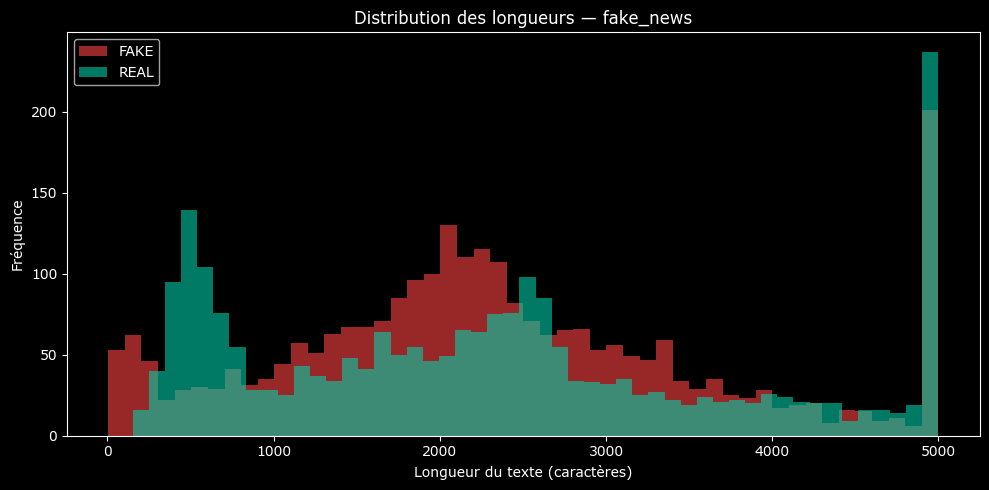

In [7]:
# Histogramme des longueurs pour la première source disponible avec texte et label
for name, df in sources.items():
    text_col = next((c for c in df.columns if c.lower() in ('text', 'statement', 'tweet')), None)
    label_col = next((c for c in df.columns if c.lower() in ('label', 'fraudulent')), None)
    if not text_col or not label_col:
        continue

    df_sample = (
        df.withColumn('text_len', F.length(F.col(text_col)))
        .select('text_len', label_col)
        .sample(fraction=min(1.0, 5000 / df.count()), seed=42)
        .toPandas()
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    for label_val, color, label_name in [(1, '#ff4444', 'FAKE'), (0, '#00ccaa', 'REAL')]:
        subset = df_sample[df_sample[label_col].astype(str).isin([str(label_val), 'FAKE' if label_val==1 else 'REAL', 'fake' if label_val==1 else 'real'])]
        if len(subset):
            ax.hist(subset['text_len'].clip(0, 5000), bins=50, alpha=0.6, color=color, label=label_name)
    
    ax.set_xlabel('Longueur du texte (caractères)')
    ax.set_ylabel('Fréquence')
    ax.set_title(f'Distribution des longueurs — {name}')
    ax.legend()
    plt.tight_layout()
    plt.show()
    break

## Section 5 — Top 20 mots les plus fréquents (FAKE vs REAL)

Calcul des top mots pour fake_news...


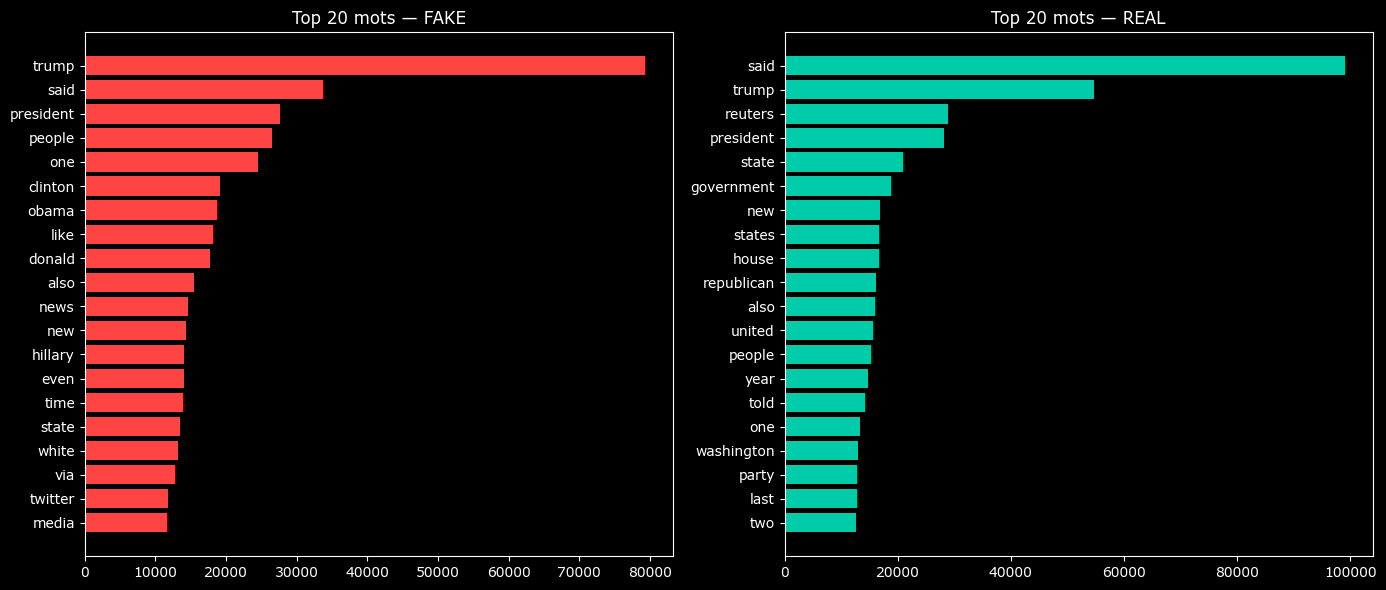

In [8]:
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover
from pyspark.ml import Pipeline

STOPWORDS = StopWordsRemover.loadDefaultStopWords('english')

def top_words(df, text_col: str, label_col: str, label_value, n: int = 20):
    """Retourne les N mots les plus fréquents pour un label donné."""
    from pyspark.sql.functions import explode, col
    
    subset = df.filter(F.col(label_col).cast('string') == str(label_value))
    tokenizer = RegexTokenizer(inputCol=text_col, outputCol='tokens_raw', pattern=r'\W+', minTokenLength=3)
    remover = StopWordsRemover(inputCol='tokens_raw', outputCol='tokens', stopWords=STOPWORDS)
    pipeline = Pipeline(stages=[tokenizer, remover])
    df_tok = pipeline.fit(subset).transform(subset)
    
    word_counts = (
        df_tok.select(explode(col('tokens')).alias('word'))
        .groupBy('word').count()
        .orderBy('count', ascending=False)
        .limit(n).toPandas()
    )
    return word_counts

for name, df in sources.items():
    text_col = next((c for c in df.columns if c.lower() in ('text', 'statement')), None)
    label_col = next((c for c in df.columns if c.lower() in ('label', 'fraudulent')), None)
    if not text_col or not label_col:
        continue

    print(f'Calcul des top mots pour {name}...')
    fake_words = top_words(df, text_col, label_col, 1)
    real_words = top_words(df, text_col, label_col, 0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.barh(fake_words['word'][::-1], fake_words['count'][::-1], color='#ff4444')
    ax1.set_title('Top 20 mots — FAKE', fontsize=12)
    ax2.barh(real_words['word'][::-1], real_words['count'][::-1], color='#00ccaa')
    ax2.set_title('Top 20 mots — REAL', fontsize=12)
    plt.tight_layout()
    plt.show()
    break

## Section 6 — Détection des doublons inter-sources

In [9]:
if len(sources) >= 2:
    all_texts = None
    for name, df in sources.items():
        text_col = next((c for c in df.columns if c.lower() in ('text', 'statement', 'tweet')), None)
        if not text_col:
            continue
        df_text = df.select(F.col(text_col).alias('text')).withColumn('source', F.lit(name))
        all_texts = df_text if all_texts is None else all_texts.union(df_text)
    
    if all_texts:
        total = all_texts.count()
        unique = all_texts.dropDuplicates(['text']).count()
        duplicates = total - unique
        print(f'\nDuplicats inter-sources :')
        print(f'  Total textes   : {total:,}')
        print(f'  Textes uniques : {unique:,}')
        print(f'  Doublons       : {duplicates:,} ({duplicates/total*100:.1f}%)')
else:
    print('Une seule source disponible — pas de doublons inter-sources à détecter')


Duplicats inter-sources :
  Total textes   : 160,516
  Textes uniques : 62,717
  Doublons       : 97,799 (60.9%)


## Section 7 — Rapport de qualité des données

In [10]:
MIN_TEXT_LENGTH = 20

quality_report = []

for name, df in sources.items():
    text_col = next((c for c in df.columns if c.lower() in ('text', 'statement', 'tweet')), None)
    if not text_col:
        continue
    
    total = df.count()
    nulls = df.filter(F.col(text_col).isNull()).count()
    empty = df.filter(F.trim(F.col(text_col)) == '').count()
    too_short = df.filter(F.length(F.col(text_col)) < MIN_TEXT_LENGTH).count()
    
    quality_report.append({
        'source': name,
        'total': total,
        'nulls': nulls,
        'empty': empty,
        'too_short (<20 chars)': too_short,
        'exploitable': total - nulls - empty,
        'qualité %': round((total - nulls - empty) / total * 100, 1) if total > 0 else 0
    })

report_df = pd.DataFrame(quality_report)
print('\n=== RAPPORT DE QUALITÉ DES DONNÉES ===')
print(report_df.to_string(index=False))

os.makedirs('../09_data/reports', exist_ok=True)
report_df.to_csv('../09_data/reports/01_quality_report.csv', index=False)
print('\n✓ Rapport sauvegardé : 09_data/reports/01_quality_report.csv')


=== RAPPORT DE QUALITÉ DES DONNÉES ===
   source  total  nulls  empty  too_short (<20 chars)  exploitable  qualité %
fake_news  44267      0      0                     39        44267      100.0
  welfake  71351      0      0                     96        71351      100.0
isot_fake  23481      0    630                    669        22851       97.3
isot_true  21417      0      1                      1        21416      100.0

✓ Rapport sauvegardé : 09_data/reports/01_quality_report.csv


In [11]:
spark.stop()
print('✓ Session Spark arrêtée')

✓ Session Spark arrêtée
